≥50% complete short-read vOTUs underwent viral family-level cluster (VFC) construction using an identical pipeline with identical reference sequences as hybrid vOTUs.

In [1]:
import pandas as pd

df_jdc = pd.read_csv('../data/hybrid_vs_shortread_comparison/shared_hybrid_shortread_votu-info.tsv', sep='\t')

Find the best-hit short-read VFC of each hybrid VFC, and best-hit hybrid VFC of each short-read VFC.

In [2]:
from statistics import mode

def most_common(x, default=-1):
    x = x.dropna()
    return mode(x) if len(x) > 0 else default

df_hybsrvc = (
    df_jdc
    .groupby('hyb_VFC', as_index=False)['sr_VFC']
    .agg(most_common)
)

df_srhybvc = (
    df_jdc
    .groupby('sr_VFC', as_index=False)['hyb_VFC']
    .agg(most_common)
)

Check if best hits are reciprocal best hits for hybrid VFCs 1-12.

In [3]:
df_besthits = (
    df_hybsrvc
    .merge(df_srhybvc, on='sr_VFC', how='left')
    .rename(columns={
        'hyb_VFC_x': 'hyb_VFC',
        'hyb_VFC_y': 'srbesthit_hyb_VFC'
    })
)
df_besthits['srbesthit_hyb_VFC'] = df_besthits['srbesthit_hyb_VFC'].fillna(-1)
df_besthits = df_besthits.astype(int)

In [4]:
df_besthits[:12]

,hyb_VFC,sr_VFC,srbesthit_hyb_VFC
0,1,619,1
1,2,543,16
2,3,83,3
3,4,545,4
4,5,678,5
5,6,633,6
6,7,780,7
7,8,394,8
8,9,428,9
9,10,531,10


&rarr; The best-hit hybrid VFC of short-read VFC 543 is VFC 16 (*Okuboviridae*), a clade related to VFC 2. This was likely due to short-read VFC construction missing out most of VFC 2!

Obtain VFC sizes.

In [5]:
df_comb_seqs = pd.read_csv('../data/hybrid_vs_shortread_comparison/hybrid_shortread_sequence-info.tsv', sep='\t')

df_srvcsize = df_comb_seqs.groupby('sr_VFC', as_index=False).seq_id.count().rename(columns={'seq_id': 'VC_size'})

df_hybvcsize = df_comb_seqs.groupby('hyb_VFC', as_index=False).seq_id.count().rename(columns={'seq_id': 'VC_size'})

Focus on hybrid VFCs 1-12.

In [6]:
topvfcs= range(1,13) # top hybrid VFCs (1-12)

df_tophybvc = df_hybsrvc.loc[df_hybsrvc.hyb_VFC.isin(topvfcs)]
df_tophybvc = df_tophybvc.astype(int)

In [7]:
df_tophybvc1 = df_tophybvc.copy()
df_tophybvc1['type'] = 'long-read'
df_tophybvc1 = df_tophybvc1.merge(df_hybvcsize, on='hyb_VFC', how='left')

df_tophybvc2 = df_tophybvc.copy()
df_tophybvc2['type'] = 'short-read'
df_tophybvc2 = df_tophybvc2.merge(df_srvcsize, on='sr_VFC', how='left')

df_tophybvc3 = pd.concat([df_tophybvc1, df_tophybvc2])

"Clustering of short-read vOTUs and reference genomes using the same approach identified far fewer members of even the most prevalent VFCs in the cohort (**<20% on average**)"

In [8]:
ratio_df = (
    df_tophybvc3.pivot(index='hyb_VFC', columns='type', values='VC_size')
      .assign(ratio=lambda x: x['short-read'] / x['long-read'])
)

In [9]:
ratio_df.ratio.describe()

count    12.000000
mean      0.191482
std       0.155871
min       0.057971
25%       0.082274
50%       0.124365
75%       0.258929
max       0.602410
Name: ratio, dtype: float64

### Supplementary Fig. 6A: short-read vs. hybrid VFC sizes

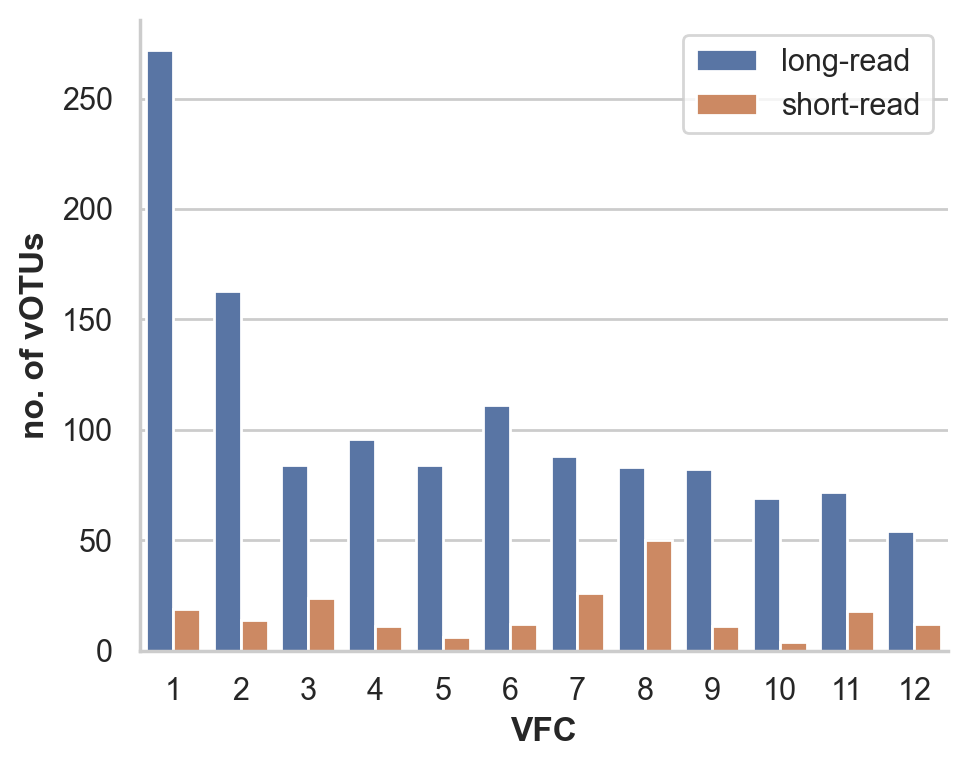

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

fig, ax = plt.subplots(figsize=(5,4), dpi=200)

g = sns.barplot(data=df_tophybvc3, x='hyb_VFC', y='VC_size', hue='type', order=topvfcs)

plt.xlabel('VFC', fontweight='bold')
plt.ylabel('no. of vOTUs', fontweight='bold')

legend_handles, _ = ax.get_legend_handles_labels()
ax.legend(legend_handles, ['long-read','short-read'], title='', loc='upper right')

sns.despine()
plt.tight_layout()